In [1]:

import os
from dotenv import load_dotenv
from mem0 import MemoryClient

os.environ["MEM0_API_KEY"] = os.getenv("MEM0_API_KEY", "")
from dotenv import load_dotenv
load_dotenv()


#!pip show crewai



True

In [2]:
# loads MEM0_API_KEY from .env
client = MemoryClient(api_key=os.getenv("MEM0_API_KEY"))
#dir(client)


# Example usage
messages = [
    { "role": "user", "content": "Hi, I'm Alex. I'm a vegetarian and I'm allergic to nuts." },
    { "role": "assistant", "content": "Hello Alex! I see that you're a vegetarian with a nut allergy." }
]

client.add(messages, user_id="alex")

{'results': [{'message': 'Memory processing has been queued for background execution',
   'status': 'PENDING',
   'event_id': 'f6a19fe0-9c82-497c-8505-8e301edd084b'}]}

In [3]:
query = "What can I cook for dinner tonight?"

filters = {
   "OR":[
      {
         "user_id":"alex"
      }
   ]
}

client.search(query, version="v2", filters=filters)

{'results': []}

MEM0 with the CrewAi Implementation

In [ ]:
import os
from mem0 import MemoryClient
from crewai import Agent, Task, Crew, Process
from crewai_tools import SerperDevTool


# Initialize Mem0 client
client = MemoryClient()

def store_user_preferences(user_id: str, conversation: list):
    """Store user preferences from conversation history"""
    client.add(conversation, user_id=user_id)

# Example conversation storage
messages = [
    {
        "role": "user",
        "content": "Hi there! I'm planning a vacation and could use some advice.",
    },
    {
        "role": "assistant",
        "content": "Hello! I'd be happy to help with your vacation planning. What kind of destination do you prefer?",
    },
    {"role": "user", "content": "I am more of a beach person than a mountain person."},
    {
        "role": "assistant",
        "content": "That's interesting. Do you like hotels or airbnb?",
    },
    {"role": "user", "content": "I like airbnb more."},
]

store_user_preferences("crew_user_1", messages)


def create_travel_agent():
    """Create a travel planning agent with search capabilities"""
    search_tool = SerperDevTool()

    return Agent(
        role="Personalized Travel Planner Agent",
        goal="Plan personalized travel itineraries",
        backstory="""You are a seasoned travel planner, known for your meticulous attention to detail.""",
        allow_delegation=False,
        memory=True,
        tools=[search_tool],
    )

def create_planning_task(agent, destination: str):
    """Create a travel planning task"""
    return Task(
        description=f"""Find places to live, eat, and visit in {destination}.""",
        expected_output=f"A detailed list of places to live, eat, and visit in {destination}.",
        agent=agent,
    )

def setup_crew(agents: list, tasks: list):
    """Set up a crew with Mem0 memory integration"""
    return Crew(
        agents=agents,
        tasks=tasks,
        process=Process.sequential,
        memory=True,
        memory_config={
            "provider": "mem0",
            "config": {"user_id": "crew_user_1"},
        }
    )


def plan_trip(destination: str, user_id: str):
    # Create agent
    travel_agent = create_travel_agent()

    # Create task
    planning_task = create_planning_task(travel_agent, destination)

    # Setup crew
    crew = setup_crew([travel_agent], [planning_task])

    # Execute and return results
    return crew.kickoff()

# Example usage
if __name__ == "__main__":
    result = plan_trip("San Francisco", "crew_user_1")
    print(result)

In [23]:
results = client.search("hello")  # search memories containing "hello"

for mem in results:
    print(mem["content"])


HTTP error occurred: Client error '400 Bad Request' for url 'https://api.mem0.ai/v2/memories/search/'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/400


ValidationError: {"error":"Filters are required and cannot be empty. Please refer to https://docs.mem0.ai/api-reference/memory/search-memories"}

HISTORY of chat we can see in the website
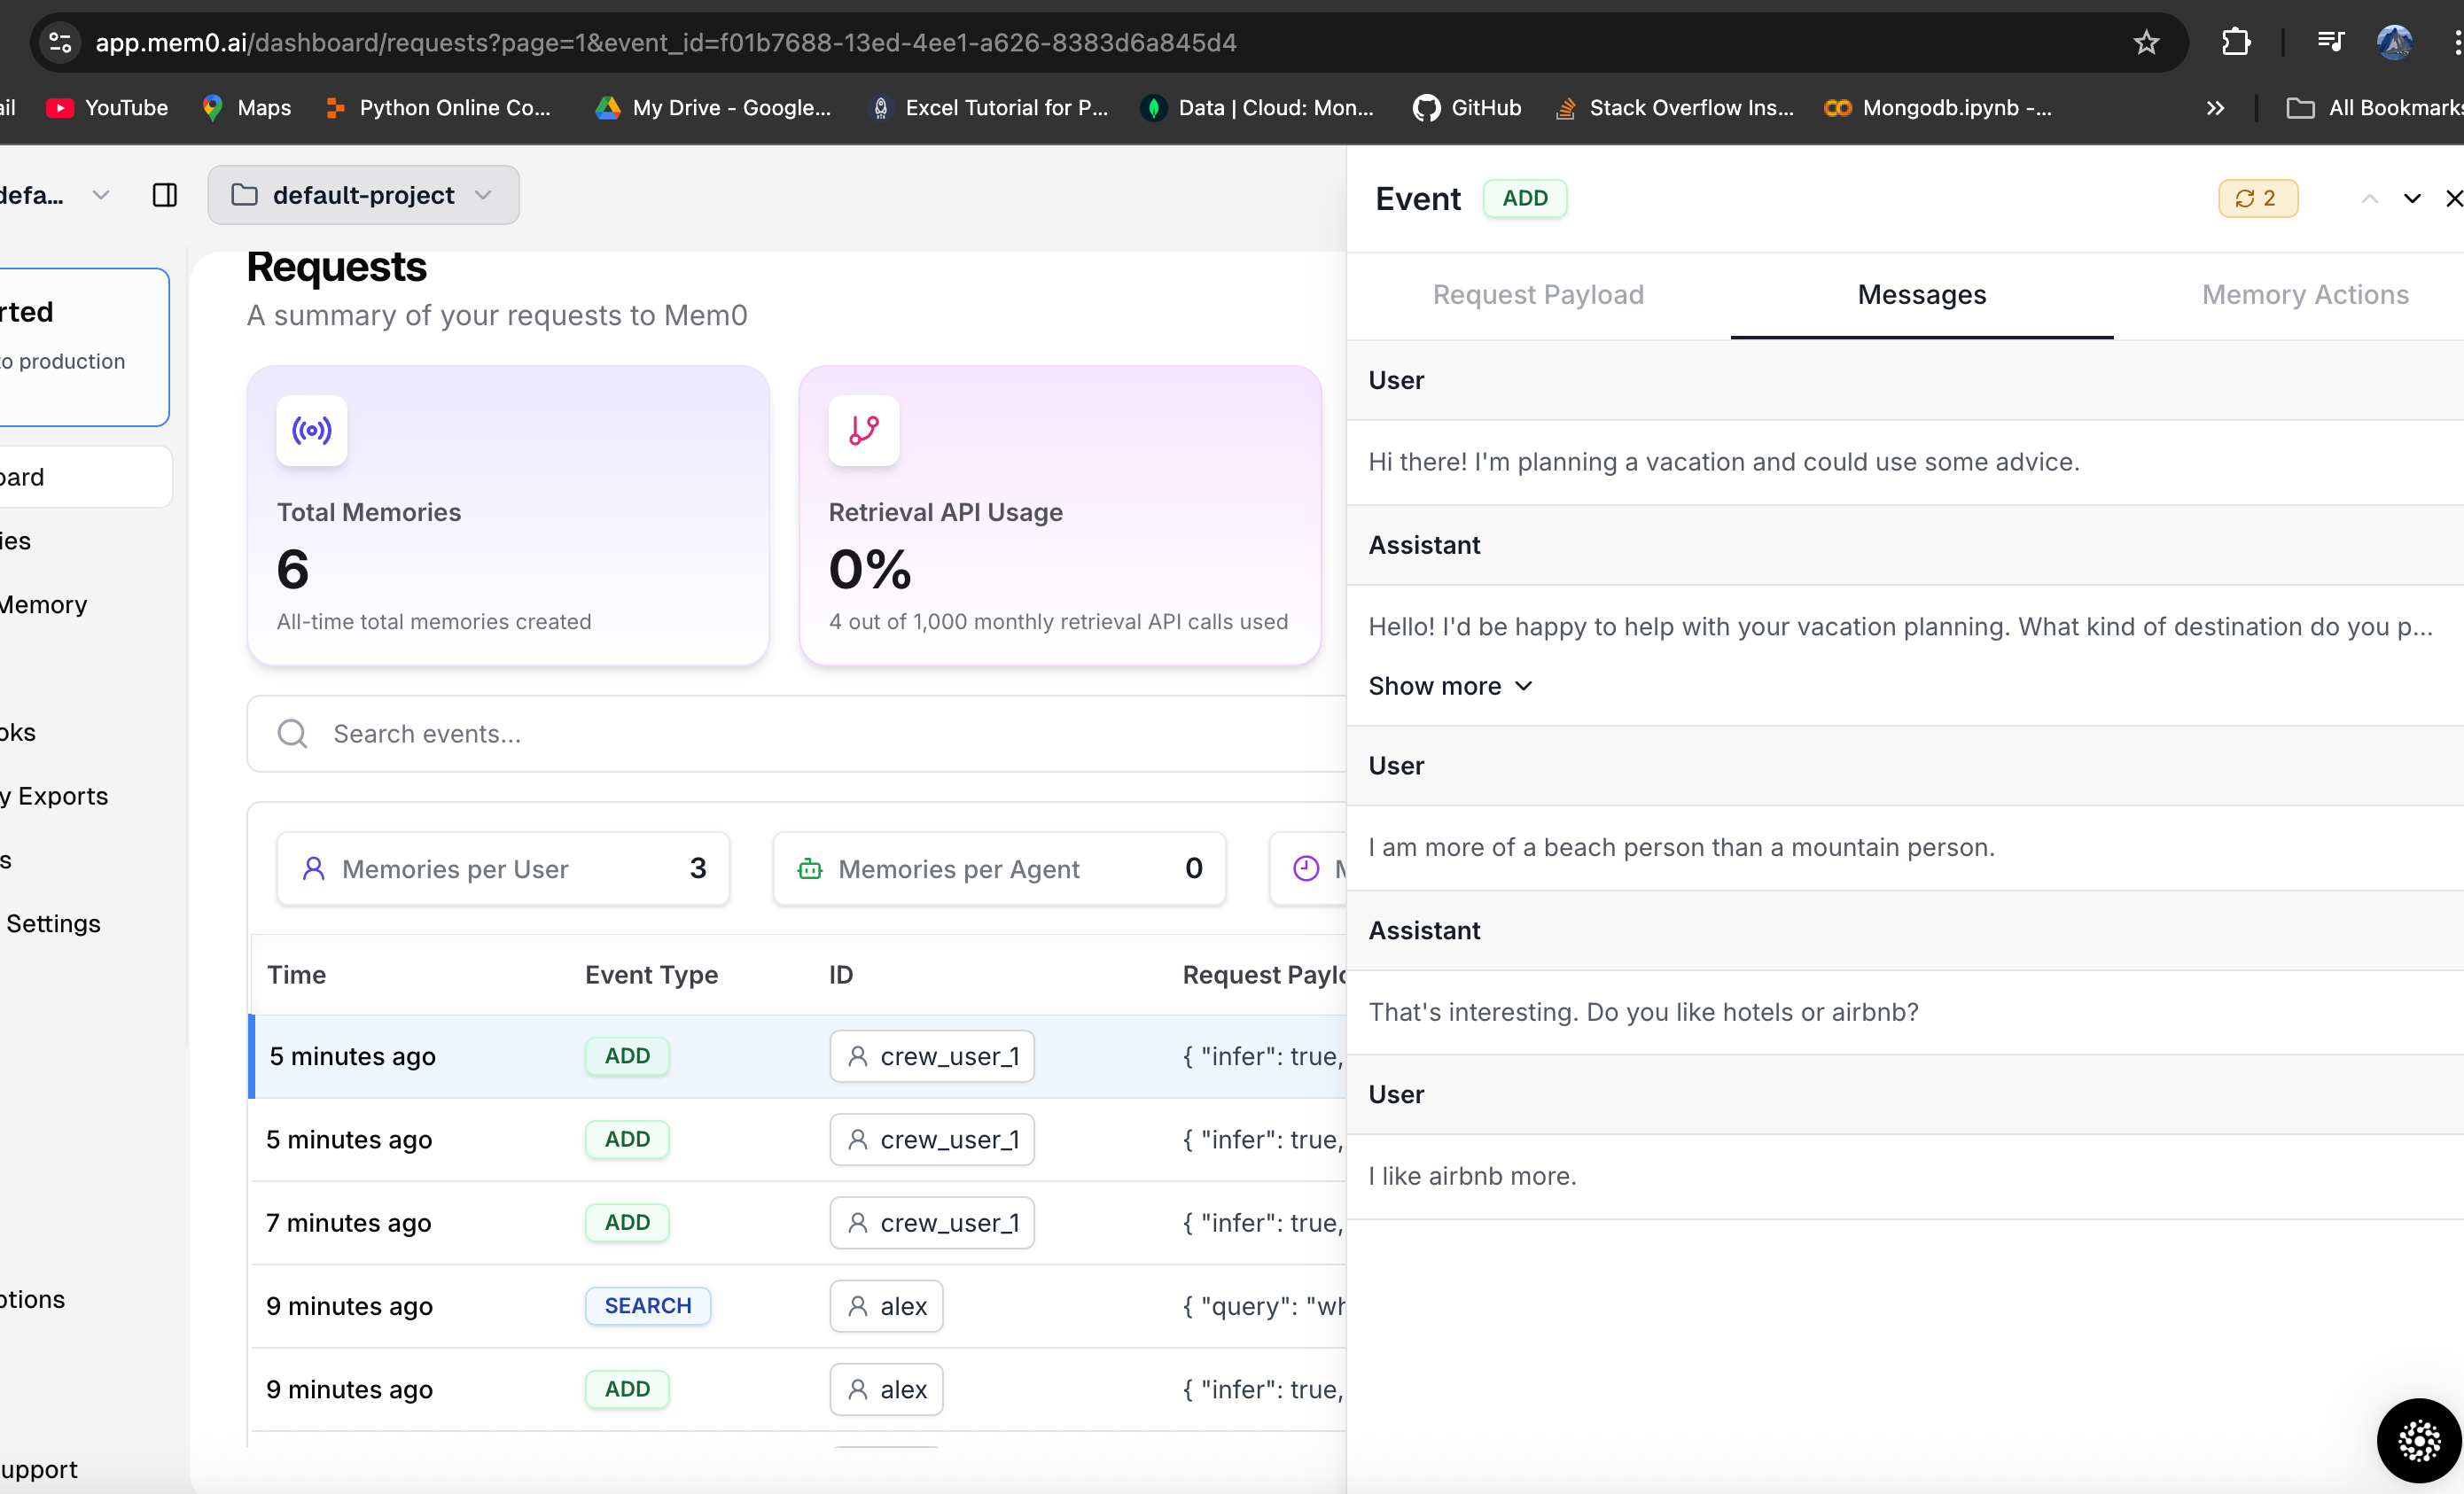